# Import libraries

In [7]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Defining Configuration

In [8]:

INITIAL_CAPITAL = 10000
SEQUENCE_LENGTH = 60  # Days to look back
HIDDEN_SIZE = 128
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 0.001
EPOCHS = 50
BATCH_SIZE = 32

# 20 stocks from 4 different industries
STOCKS = {
    'Technology': ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'META'],
    'Healthcare': ['JNJ', 'UNH', 'PFE', 'ABBV', 'LLY'],
    'Financial': ['JPM', 'BAC', 'WFC', 'GS', 'MS'],
    'Consumer': ['AMZN', 'TSLA', 'HD', 'MCD', 'NKE']
}

ALL_STOCKS = [stock for stocks in STOCKS.values() for stock in stocks]
BENCHMARK = '^GSPC'  # S&P 500

# Dataset acquisition

In [ ]:
def download_stock_data(tickers, start_date, end_date):
    """Download stock data for given tickers"""
    print(f"Downloading data for {len(tickers)} stocks...")
    data = {}
    failed_tickers = []
    
    for ticker in tickers:
        try:
            df = yf.download(ticker, start=start_date, end=end_date, 
                           progress=False, auto_adjust=True)
            
            if df.empty:
                print(f"  ✗ Warning: No data for {ticker}")
                failed_tickers.append(ticker)
                continue
            
            # Handle both single-level and multi-level column indices
            if 'Close' in df.columns:
                close_prices = df['Close']
            elif isinstance(df.columns, pd.MultiIndex):
                close_prices = df['Close'][ticker] if ticker in df['Close'].columns else df['Close'].iloc[:, 0]
            else:
                # Assume it's already the close prices
                close_prices = df
            
            # Ensure it's a Series with DatetimeIndex
            if isinstance(close_prices, pd.DataFrame):
                close_prices = close_prices.iloc[:, 0]
            
            if len(close_prices) > 0:
                data[ticker] = close_prices
                print(f"  ✓ {ticker}: {len(close_prices)} days")
            else:
                print(f"  ✗ Warning: Empty data for {ticker}")
                failed_tickers.append(ticker)
                
        except Exception as e:
            print(f"  ✗ Error downloading {ticker}: {e}")
            failed_tickers.append(ticker)
    
    if not data:
        raise ValueError(f"No stock data was successfully downloaded! Failed tickers: {failed_tickers}")
    
    if failed_tickers:
        print(f"\nFailed to download: {failed_tickers}")
    
    print(f"\n✓ Successfully downloaded {len(data)}/{len(tickers)} stocks")
    
    # Create DataFrame with proper alignment
    result = pd.DataFrame(data)
    return result.fillna(method='ffill').fillna(method='bfill')


def create_sequences(data, seq_length):
    """Create sequences for LSTM training"""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)



# Model Definition

In [10]:
class LSTMPredictor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super(LSTMPredictor, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]  # Take last time step
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out


# Training Pipeline

In [11]:
def train_model(model, train_loader, criterion, optimizer, device, epochs):
    model.train()
    train_losses = []
    
    for epoch in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions.squeeze(), y_batch)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}')
    
    return train_losses



# Portfolio optimization

In [12]:
class PortfolioManager:
    def __init__(self, initial_capital, stocks):
        self.initial_capital = initial_capital
        self.cash = initial_capital
        self.stocks = stocks
        self.holdings = {stock: 0 for stock in stocks}
        self.portfolio_values = []
        self.trades = []
        
    def execute_trade(self, stock, shares, price, date, action):
        """Execute a buy or sell trade"""
        if action == 'BUY':
            cost = shares * price
            if cost <= self.cash:
                self.cash -= cost
                self.holdings[stock] += shares
                self.trades.append({
                    'Date': date,
                    'Stock': stock,
                    'Action': 'BUY',
                    'Shares': shares,
                    'Price': price,
                    'Cost': cost,
                    'Cash_After': self.cash
                })
        elif action == 'SELL':
            if self.holdings[stock] >= shares:
                proceeds = shares * price
                self.cash += proceeds
                self.holdings[stock] -= shares
                self.trades.append({
                    'Date': date,
                    'Stock': stock,
                    'Action': 'SELL',
                    'Shares': shares,
                    'Price': price,
                    'Cost': proceeds,
                    'Cash_After': self.cash
                })
    
    def get_portfolio_value(self, prices):
        stock_value = sum(self.holdings[stock] * prices.get(stock, 0) 
                         for stock in self.stocks)
        return self.cash + stock_value
    
    def get_portfolio_breakdown(self, prices):
        breakdown = []
        total_value = 0
        
        for stock in self.stocks:
            shares = self.holdings[stock]
            if shares > 0:
                price = prices.get(stock, 0)
                value = shares * price
                total_value += value
                breakdown.append({
                    'Stock': stock,
                    'Shares': shares,
                    'Price': price,
                    'Value': value
                })
        
        # Add cash position
        breakdown.append({
            'Stock': 'CASH',
            'Shares': 1,
            'Price': self.cash,
            'Value': self.cash
        })
        total_value += self.cash
        
        # Add percentage allocations
        for item in breakdown:
            item['Allocation (%)'] = (item['Value'] / total_value * 100) if total_value > 0 else 0
        
        return breakdown, total_value
    
    def rebalance_portfolio(self, predictions, prices, date):
        # Sort stocks by predicted return
        stock_scores = [(stock, pred) for stock, pred in zip(self.stocks, predictions)]
        stock_scores.sort(key=lambda x: x[1], reverse=True)
        
        # Select top 10 stocks
        top_stocks = [stock for stock, _ in stock_scores[:10]]
        
        # Sell stocks not in top 10
        for stock in self.stocks:
            if stock not in top_stocks and self.holdings[stock] > 0:
                shares_to_sell = self.holdings[stock]
                self.execute_trade(stock, shares_to_sell, prices[stock], date, 'SELL')
        
        # Calculate allocation for top stocks
        total_value = self.get_portfolio_value(prices)
        allocation_per_stock = total_value / len(top_stocks) * 0.95  # Keep 5% cash
        
        # Buy/adjust positions in top stocks
        for stock in top_stocks:
            target_value = allocation_per_stock
            current_value = self.holdings[stock] * prices[stock]
            
            if current_value < target_value:
                # Buy more
                shares_to_buy = int((target_value - current_value) / prices[stock])
                if shares_to_buy > 0:
                    self.execute_trade(stock, shares_to_buy, prices[stock], date, 'BUY')


LSTM Portfolio Optimization System
  ✓ AAPL: 752 days
  ✓ MSFT: 752 days
  ✓ NVDA: 752 days
  ✓ GOOGL: 752 days
  ✓ META: 752 days
  ✓ JNJ: 752 days
  ✓ UNH: 752 days
  ✓ PFE: 752 days
  ✓ ABBV: 752 days
  ✓ LLY: 752 days
  ✓ JPM: 752 days
  ✓ BAC: 752 days
  ✓ WFC: 752 days
  ✓ GS: 752 days
  ✓ MS: 752 days
  ✓ AMZN: 752 days
  ✓ TSLA: 752 days
  ✓ HD: 752 days
  ✓ MCD: 752 days
  ✓ NKE: 752 days
  ✓ ^GSPC: 752 days

✓ Successfully downloaded 21/21 stocks

Available stocks after cleaning: 20
Training period: 2022-11-02 00:00:00 to 2025-03-27 00:00:00
Testing period: 2025-03-28 00:00:00 to 2025-10-31 00:00:00

Using device: cuda

Training LSTM model...
Epoch [10/50], Loss: 0.005547
Epoch [20/50], Loss: 0.004657
Epoch [30/50], Loss: 0.004743
Epoch [40/50], Loss: 0.004067
Epoch [50/50], Loss: 0.003478

Backtesting strategy...

RESULTS
Initial Capital: $10,000.00
Final Portfolio Value: $11,833.98
Final Benchmark Value: $11,227.87
Portfolio Return: 18.34%
Benchmark Return: 12.28%
Outperfor

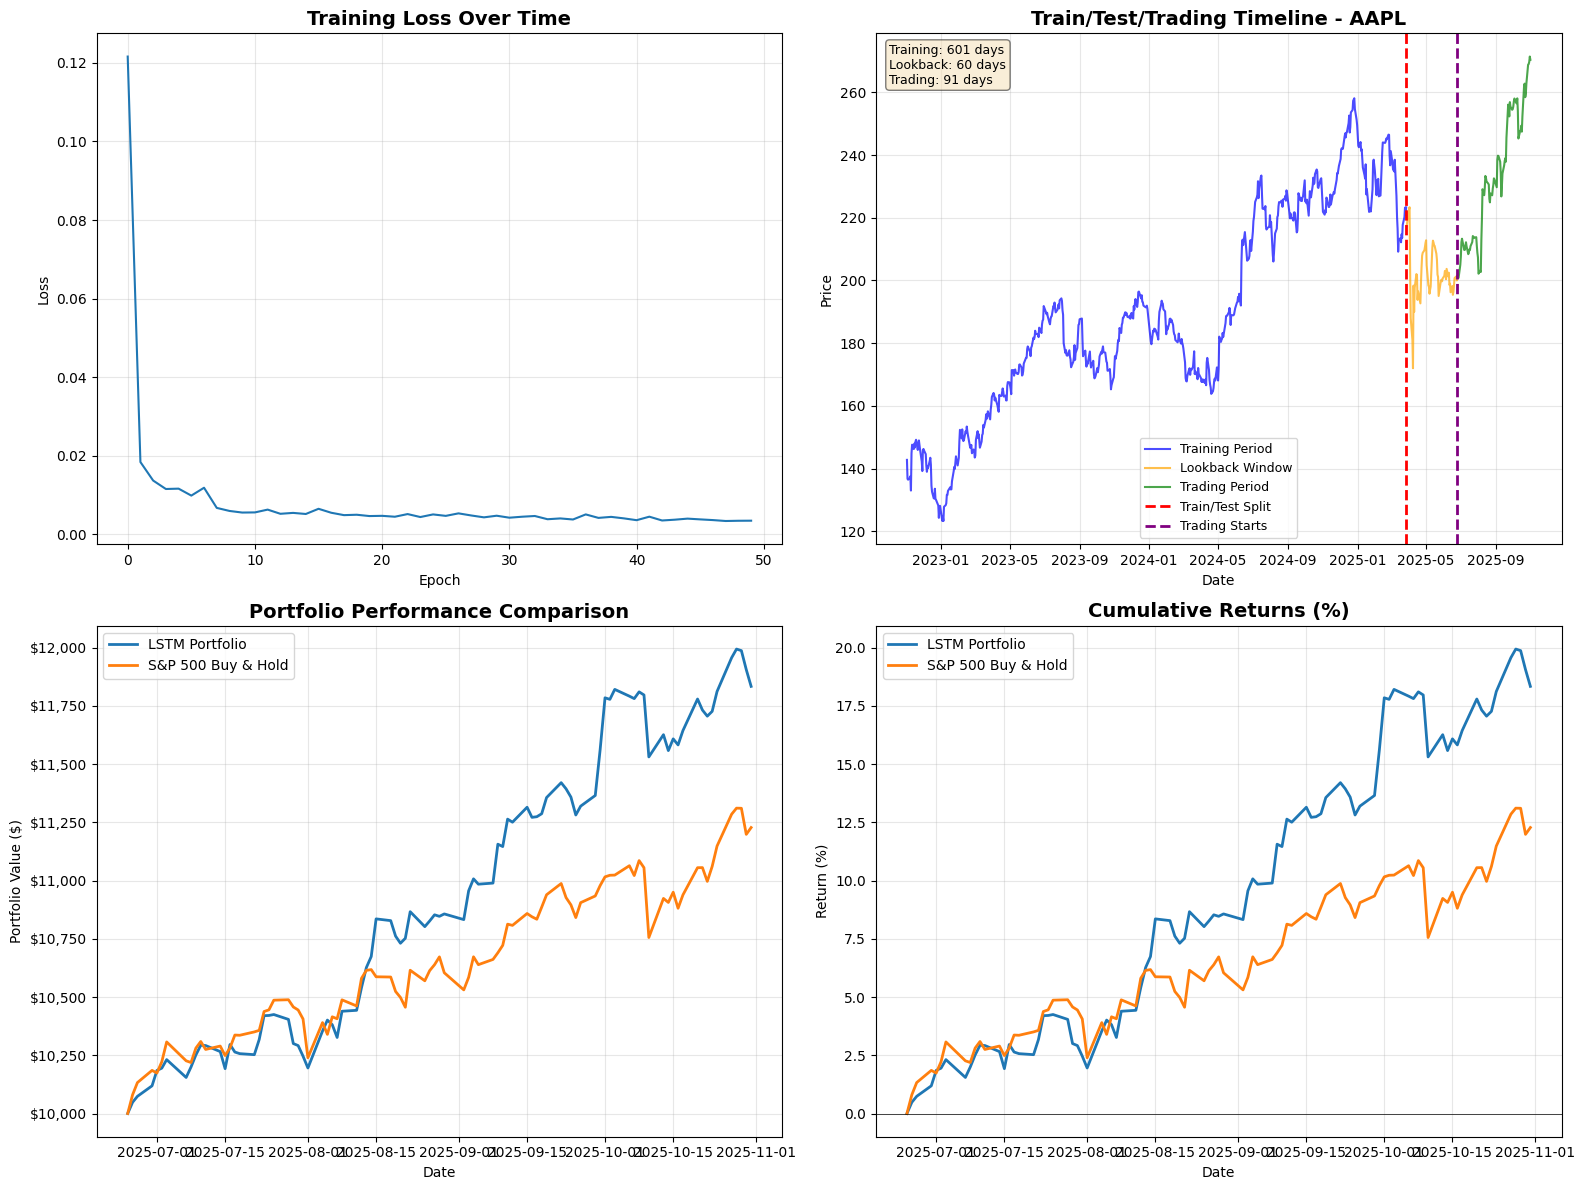

In [13]:
def main():
    print("=" * 60)
    print("LSTM Portfolio Optimization System")
    print("=" * 60)
    
    # Set dates
    end_date = datetime.now()
    start_date = end_date - timedelta(days=1095)  # 3 years of data
    
    # Download data
    stock_data = download_stock_data(ALL_STOCKS + [BENCHMARK], 
                                     start_date.strftime('%Y-%m-%d'), 
                                     end_date.strftime('%Y-%m-%d'))
    
    # Remove any stocks with missing data
    stock_data = stock_data.dropna(axis=1)
    available_stocks = [col for col in stock_data.columns if col != BENCHMARK]
    print(f"\nAvailable stocks after cleaning: {len(available_stocks)}")
    
    # Split into train/test (80/20)
    split_idx = int(len(stock_data) * 0.8)
    train_data = stock_data[:split_idx]
    test_data = stock_data[split_idx:]
    
    print(f"Training period: {train_data.index[0]} to {train_data.index[-1]}")
    print(f"Testing period: {test_data.index[0]} to {test_data.index[-1]}")
    
    # Prepare training data
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data[available_stocks])
    
    X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH)
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train[:, 0])  # Predict first stock as example
    
    # Create data loader
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # Initialize model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\nUsing device: {device}")
    
    model = LSTMPredictor(input_size=len(available_stocks), 
                         hidden_size=HIDDEN_SIZE, 
                         num_layers=NUM_LAYERS, 
                         dropout=DROPOUT).to(device)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Train model
    print("\nTraining LSTM model...")
    train_losses = train_model(model, train_loader, criterion, optimizer, device, EPOCHS)
    
    # Prepare test data
    test_scaled = scaler.transform(test_data[available_stocks])
    
    # Initialize portfolio
    portfolio = PortfolioManager(INITIAL_CAPITAL, available_stocks)
    portfolio_values = []
    benchmark_values = []
    dates = []
    
    # Initial benchmark investment - start from same point as portfolio (after SEQUENCE_LENGTH)
    initial_spy_price = test_data[BENCHMARK].iloc[SEQUENCE_LENGTH]
    spy_shares = INITIAL_CAPITAL / initial_spy_price
    
    print("\nBacktesting strategy...")
    model.eval()
    
    with torch.no_grad():
        for i in range(SEQUENCE_LENGTH, len(test_scaled)):
            # Get sequence
            sequence = test_scaled[i-SEQUENCE_LENGTH:i]
            X = torch.FloatTensor(sequence).unsqueeze(0).to(device)
            
            # Predict returns for all stocks
            predictions = []
            for j in range(len(available_stocks)):
                pred = model(X)
                predictions.append(pred.item())
            
            # Get current prices
            current_date = test_data.index[i]
            current_prices = {stock: test_data[stock].iloc[i] for stock in available_stocks}
            
            # Rebalance portfolio every 5 days
            if i % 5 == 0:
                portfolio.rebalance_portfolio(predictions, current_prices, current_date)
            
            # Record portfolio value
            portfolio_value = portfolio.get_portfolio_value(current_prices)
            portfolio_values.append(portfolio_value)
            
            # Record benchmark value
            benchmark_value = spy_shares * test_data[BENCHMARK].iloc[i]
            benchmark_values.append(benchmark_value)
            
            dates.append(current_date)
    
    # Calculate returns
    portfolio_return = (portfolio_values[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    benchmark_return = (benchmark_values[-1] - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100
    
    print("\n" + "=" * 60)
    print("RESULTS")
    print("=" * 60)
    print(f"Initial Capital: ${INITIAL_CAPITAL:,.2f}")
    print(f"Final Portfolio Value: ${portfolio_values[-1]:,.2f}")
    print(f"Final Benchmark Value: ${benchmark_values[-1]:,.2f}")
    print(f"Portfolio Return: {portfolio_return:.2f}%")
    print(f"Benchmark Return: {benchmark_return:.2f}%")
    print(f"Outperformance: {portfolio_return - benchmark_return:.2f}%")
    print(f"Total Trades: {len(portfolio.trades)}")
    
    # Get final portfolio breakdown
    final_prices = {stock: test_data[stock].iloc[-1] for stock in available_stocks}
    breakdown, total_value = portfolio.get_portfolio_breakdown(final_prices)
    
    print("\n" + "=" * 60)
    print("FINAL PORTFOLIO BREAKDOWN")
    print("=" * 60)
    breakdown_df = pd.DataFrame(breakdown)
    print(breakdown_df.to_string(index=False))
    
    print("\n" + "=" * 60)
    print("RECENT TRANSACTIONS (Last 20)")
    print("=" * 60)
    if len(portfolio.trades) > 0:
        recent_trades = portfolio.trades[-20:] if len(portfolio.trades) > 20 else portfolio.trades
        trades_display = pd.DataFrame(recent_trades)
        print(trades_display.to_string(index=False))
    else:
        print("No trades executed")
    
    # Create output directory
    import os
    output_dir = './outputs'
    os.makedirs(output_dir, exist_ok=True)
    
    # Save portfolio breakdown
    breakdown_df.to_csv(os.path.join(output_dir, 'final_portfolio_breakdown.csv'), index=False)
    print(f"✓ Portfolio breakdown saved to {output_dir}/final_portfolio_breakdown.csv")
    
    # Save ALL trades to CSV
    trades_df = pd.DataFrame(portfolio.trades)
    trades_df.to_csv(os.path.join(output_dir, 'all_portfolio_trades.csv'), index=False)
    print(f"✓ All trades ({len(portfolio.trades)}) saved to {output_dir}/all_portfolio_trades.csv")
    
    # Create visualizations
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Training Loss
    axes[0, 0].plot(train_losses)
    axes[0, 0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Train/Test Split Visualization with Trading Period
    # Show the actual trading period that starts after SEQUENCE_LENGTH
    trading_start_date = test_data.index[SEQUENCE_LENGTH]
    
    axes[0, 1].plot(train_data.index, train_data[available_stocks[0]], label='Training Period', alpha=0.7, color='blue')
    axes[0, 1].plot(test_data.index[:SEQUENCE_LENGTH], test_data[available_stocks[0]].iloc[:SEQUENCE_LENGTH], 
                   label='Lookback Window', alpha=0.7, color='orange')
    axes[0, 1].plot(test_data.index[SEQUENCE_LENGTH:], test_data[available_stocks[0]].iloc[SEQUENCE_LENGTH:], 
                   label='Trading Period', alpha=0.7, color='green')
    
    # Add vertical lines
    axes[0, 1].axvline(x=train_data.index[-1], color='red', linestyle='--', linewidth=2, label='Train/Test Split')
    axes[0, 1].axvline(x=trading_start_date, color='purple', linestyle='--', linewidth=2, label='Trading Starts')
    
    axes[0, 1].set_title(f'Train/Test/Trading Timeline - {available_stocks[0]}', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('Price')
    axes[0, 1].legend(loc='best', fontsize=9)
    axes[0, 1].grid(True, alpha=0.3)
    
    # Add text annotations
    axes[0, 1].text(0.02, 0.98, f'Training: {len(train_data)} days\nLookback: {SEQUENCE_LENGTH} days\nTrading: {len(test_data)-SEQUENCE_LENGTH} days',
                   transform=axes[0, 1].transAxes, fontsize=9,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # 3. Portfolio Value vs Benchmark
    axes[1, 0].plot(dates, portfolio_values, label='LSTM Portfolio', linewidth=2)
    axes[1, 0].plot(dates, benchmark_values, label='S&P 500 Buy & Hold', linewidth=2)
    axes[1, 0].set_title('Portfolio Performance Comparison', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Portfolio Value ($)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
    
    # 4. Cumulative Returns
    portfolio_returns = [(v - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100 for v in portfolio_values]
    benchmark_returns = [(v - INITIAL_CAPITAL) / INITIAL_CAPITAL * 100 for v in benchmark_values]
    
    axes[1, 1].plot(dates, portfolio_returns, label='LSTM Portfolio', linewidth=2)
    axes[1, 1].plot(dates, benchmark_returns, label='S&P 500 Buy & Hold', linewidth=2)
    axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1, 1].set_title('Cumulative Returns (%)', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Date')
    axes[1, 1].set_ylabel('Return (%)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'portfolio_analysis.png'), dpi=300, bbox_inches='tight')
    print(f"Visualizations saved to {output_dir}/portfolio_analysis.png")
    
    # Create detailed performance summary
    summary = {
        'Metric': [
            'Initial Capital',
            'Final Portfolio Value',
            'Final Benchmark Value',
            'Portfolio Return (%)',
            'Benchmark Return (%)',
            'Outperformance (%)',
            'Total Trades',
            'Training Period',
            'Lookback Window',
            'Trading Period (Actual)'
        ],
        'Value': [
            f'${INITIAL_CAPITAL:,.2f}',
            f'${portfolio_values[-1]:,.2f}',
            f'${benchmark_values[-1]:,.2f}',
            f'{portfolio_return:.2f}%',
            f'{benchmark_return:.2f}%',
            f'{portfolio_return - benchmark_return:.2f}%',
            len(portfolio.trades),
            f'{train_data.index[0].date()} to {train_data.index[-1].date()} ({len(train_data)} days)',
            f'{test_data.index[0].date()} to {test_data.index[SEQUENCE_LENGTH-1].date()} ({SEQUENCE_LENGTH} days)',
            f'{test_data.index[SEQUENCE_LENGTH].date()} to {test_data.index[-1].date()} ({len(test_data)-SEQUENCE_LENGTH} days)'
        ]
    }
    
    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(os.path.join(output_dir, 'performance_summary.csv'), index=False)
    print(f"Performance summary saved to {output_dir}/performance_summary.csv")
    
    print("\n" + "=" * 60)
    print("Analysis complete!")
    print("=" * 60)


if __name__ == "__main__":
    main()